In [186]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [222]:
%run '../src/functions.py'

In [188]:
sns.set(
    rc={
        "figure.figsize": (9, 6), 
        "axes.titlesize": 20, 
        "axes.labelsize": 14, 
        "xtick.labelsize": 13, 
        "ytick.labelsize": 13, 
    }
)

sns.set_style("whitegrid")

In [189]:
read_csv('/path/to/ALY6040/House Price India.csv')


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,6762830250,42734,2,1.50,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14616,6762830339,42734,3,2.00,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14617,6762830618,42734,2,1.00,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14618,6762830709,42734,4,1.00,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000


In [190]:
EDA(df)

(           id  number_of_bedrooms  number_of_bathrooms  living_area  lot_area  \
 0  6762810145                   5                 2.50         3650      9050   
 1  6762810635                   4                 2.50         2920      4000   
 2  6762810998                   5                 2.75         2910      9480   
 3  6762812605                   4                 2.50         3310     42998   
 4  6762812919                   3                 2.00         2710      4500   
 
    number_of_floors  waterfront_present  number_of_views  \
 0               2.0                   0                4   
 1               1.5                   0                0   
 2               1.5                   0                0   
 3               2.0                   0                0   
 4               1.5                   0                0   
 
    condition_of_the_house  grade_of_the_house  ...  renovation_year  \
 0                       5                  10  ...               

In [191]:
df.rename(columns=rename_columns, inplace=True)
df

,id,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,...,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price,renovation
0,6762810145,5,2.50,3650,9050,2.0,0,4,5,10,...,0,122003,52.8645,-114.557,2880,5400,2,58,2380000,0
1,6762810635,4,2.50,2920,4000,1.5,0,0,5,8,...,0,122004,52.8878,-114.470,2470,4000,2,51,1400000,0
2,6762810998,5,2.75,2910,9480,1.5,0,0,3,8,...,0,122004,52.8852,-114.468,2940,6600,1,53,1200000,0
3,6762812605,4,2.50,3310,42998,2.0,0,0,3,9,...,0,122005,52.9532,-114.321,3350,42847,3,76,838000,0
4,6762812919,3,2.00,2710,4500,1.5,0,0,4,8,...,0,122006,52.9047,-114.485,2060,4500,1,51,805000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,6762830250,2,1.50,1556,20000,1.0,0,0,4,7,...,0,122066,52.6191,-114.472,2250,17286,3,76,221700,0
14616,6762830339,3,2.00,1680,7000,1.5,0,0,4,7,...,0,122072,52.5075,-114.393,1540,7480,3,59,219200,0
14617,6762830618,2,1.00,1070,6120,1.0,0,0,3,6,...,0,122056,52.7289,-114.507,1130,6120,2,64,209000,0
14618,6762830709,4,1.00,1030,6621,1.0,0,0,4,6,...,0,122042,52.7157,-114.411,1420,6631,3,54,205000,0


In [192]:

df.rename(columns={'area_of_the_house(excluding_basement)': 'area_of_the_house'}, inplace=True)

In [193]:
df_columns = df[['number_of_bedrooms', 'number_of_bathrooms',
       'living_area', 'lot_area', 'number_of_floors', 'waterfront_present',
       'number_of_views', 'condition_of_the_house', 'grade_of_the_house',
       'area_of_the_house', 'area_of_the_basement',
       'built_year', 'renovation_year', 'living_area_renov', 'lot_area_renov',
       'number_of_schools_nearby', 'distance_from_the_airport', 'price']]
df_columns.describe()

,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,area_of_the_house,area_of_the_basement,built_year,renovation_year,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price
count,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,7.682421,1801.783926,296.479070,1970.926402,90.924008,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,1.175033,833.809963,448.551409,29.493625,416.216661,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,4.000000,370.000000,0.000000,1900.000000,0.000000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1580.000000,0.000000,1975.000000,0.000000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2240.000000,580.000000,1997.000000,0.000000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [194]:
df1 = df.sort_values(by='built_year')
df1

,id,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,...,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price,renovation
1735,6762821839,3,1.75,1680,3000,1.0,0,2,4,6,...,0,122028,52.9160,-114.536,1540,3700,2,53,425000,0
11430,6762813535,3,2.75,1960,6390,1.5,0,2,5,8,...,0,122044,52.8332,-114.475,2440,5870,1,58,759000,0
12867,6762813765,3,3.50,4380,6350,2.0,0,0,3,8,...,1999,122007,52.9281,-114.558,1830,6350,1,78,740500,1
12092,6762824778,3,1.00,1760,3000,1.5,0,0,1,6,...,0,122028,52.8898,-114.538,1320,1266,2,80,352950,0
1513,6762810639,4,3.25,2980,7000,2.0,0,3,3,10,...,2014,122054,52.8233,-114.482,2200,4800,3,53,1400000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,6762816470,4,3.25,3730,4560,2.0,0,0,3,9,...,0,122028,52.9025,-114.520,1800,4560,3,80,595000,0
13051,6762817407,2,3.00,1650,960,3.0,0,0,3,8,...,0,122028,52.8911,-114.536,1650,3000,3,80,559000,0
6146,6762829970,3,1.50,1040,1264,2.0,0,0,3,9,...,0,122054,52.8251,-114.491,1350,3000,2,69,230000,0
1044,6762819469,5,3.50,4460,2975,3.0,0,2,3,10,...,0,122003,52.8613,-114.560,2490,4231,1,59,490000,0


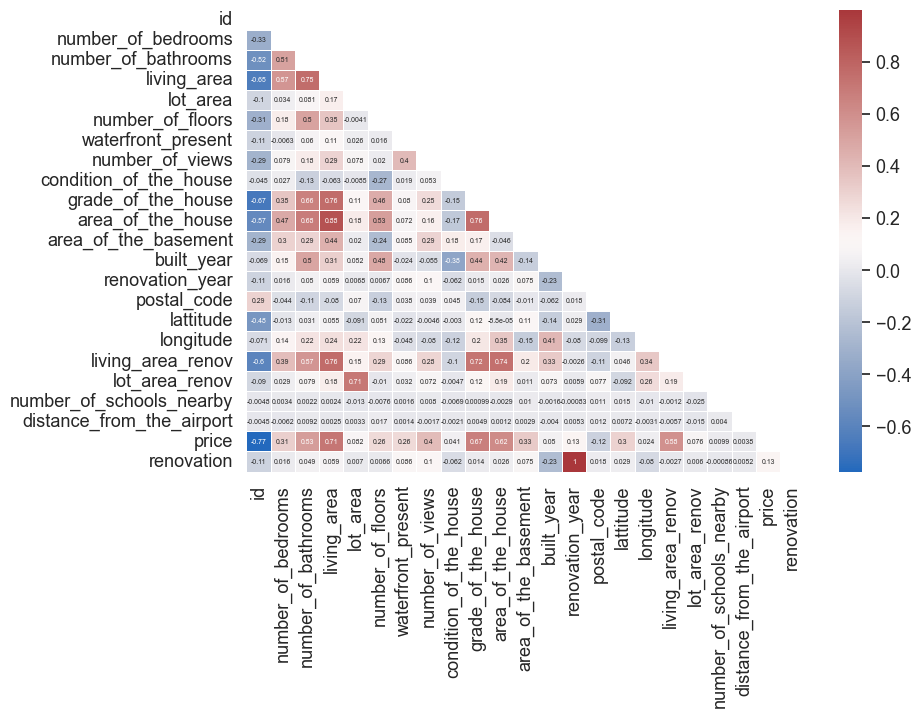

In [195]:
matrix = np.triu(df1.corr())
sns.heatmap(df1.corr(), mask=matrix, cmap='vlag',
            linewidths=0.5, linecolor='white',annot=True, annot_kws={'size':5});

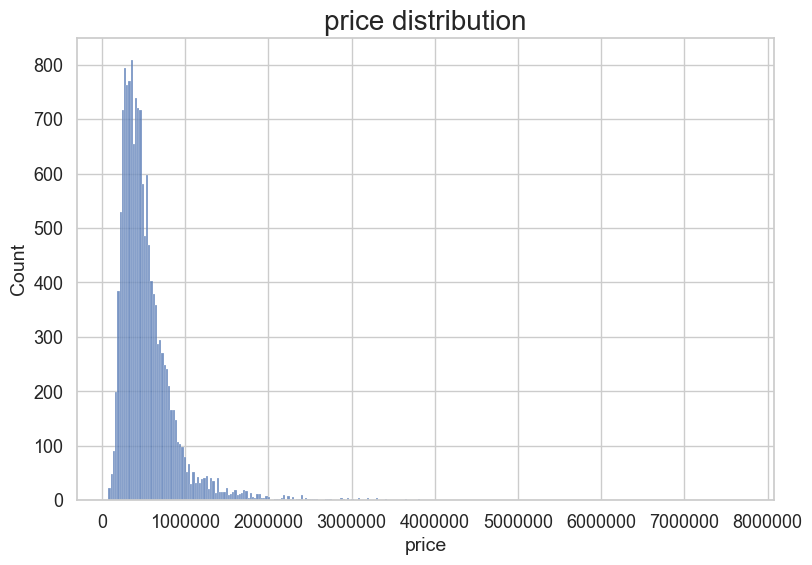

In [196]:
histogram(df1.price)

In [197]:
def renovation_cat(column):
    if column == 0:
        return 0
    else:
        return 1

In [198]:
df1['renovation'] = df1['renovation_year'].apply(renovation_cat)

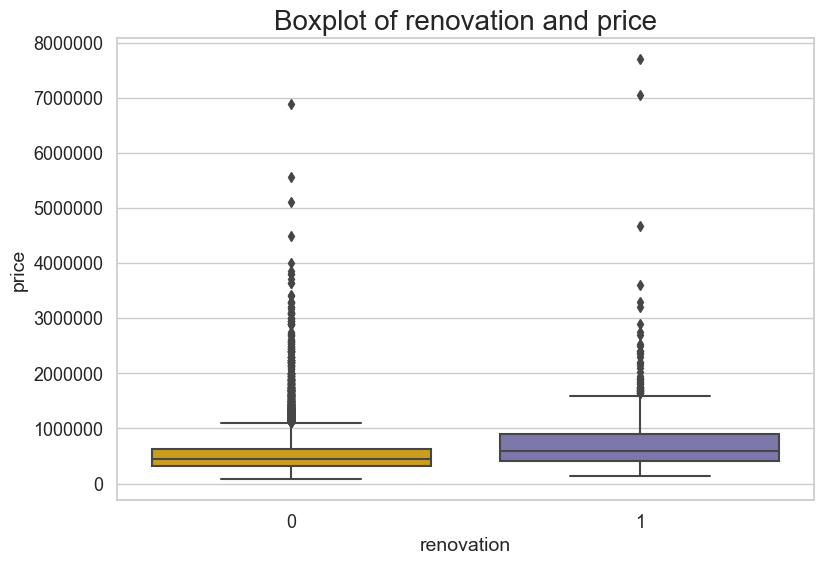

In [199]:
boxplot(df1.renovation, df1.price)

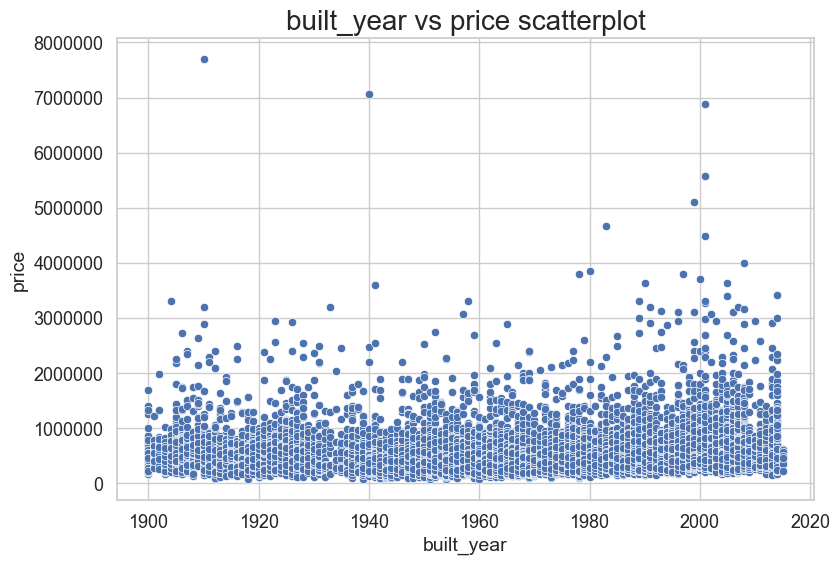

In [200]:
scatter(df1.built_year, df1.price)

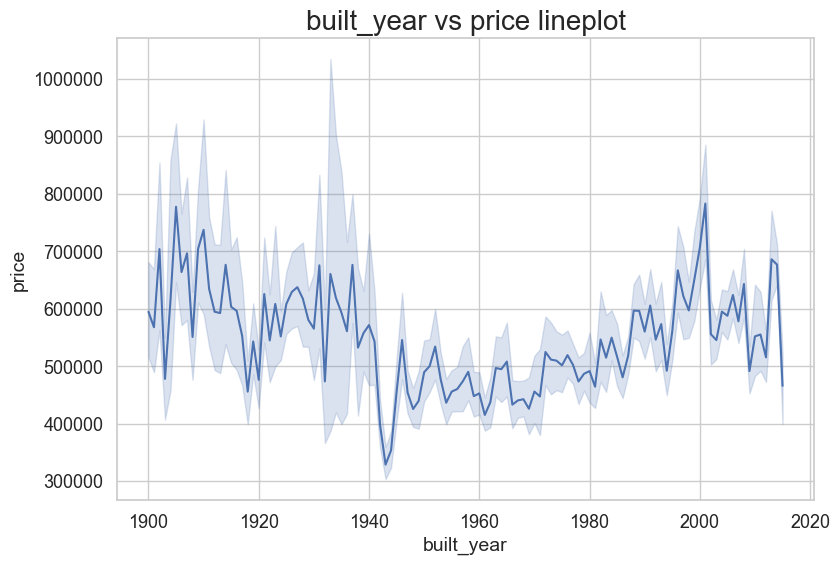

In [201]:
line(df1.built_year, df1.price)

In [212]:
# Define features and target variable
features = ['number_of_bedrooms', 'number_of_bathrooms', 'living_area', 'lot_area', 'number_of_floors', 'waterfront_present', 'number_of_views', 'condition_of_the_house', 'grade_of_the_house', 'area_of_the_house', 'area_of_the_basement', 'built_year', 'renovation_year', 'living_area_renov', 'lot_area_renov', 'number_of_schools_nearby', 'distance_from_the_airport']
target = 'price'

In [223]:
decisiontreemodel(df1, features, target)

Best hyperparameters:  {'max_depth': 6, 'min_samples_split': 2}
Best RMSE score:  0.6356046778301965
Root Mean Squared Error: 228758.4736380267


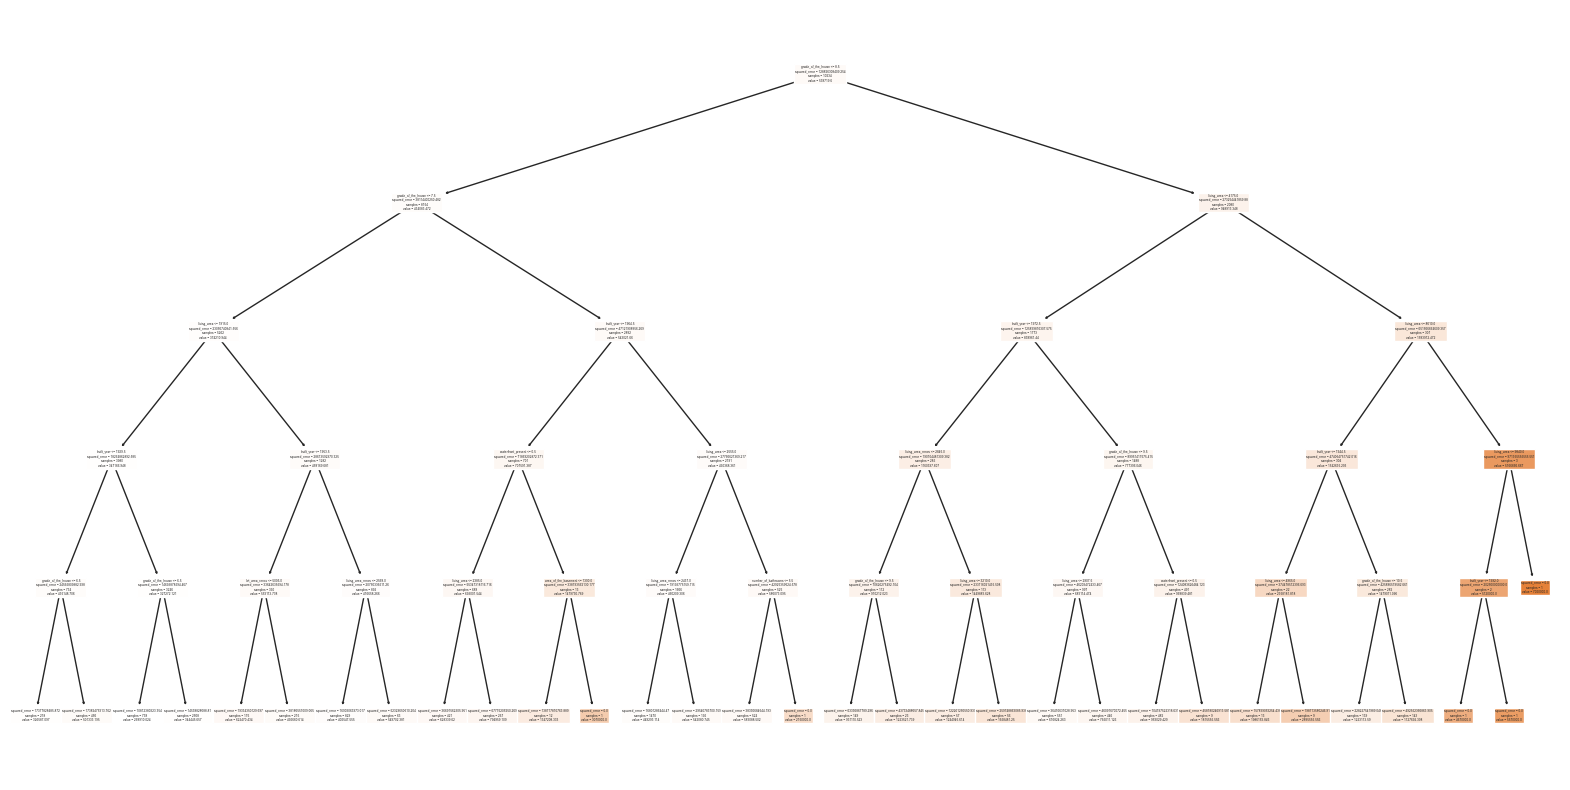

In [224]:
decisiontree(df1, features, target, max_depth=6)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best Score: 179786.08193958836
Root Mean Squared Error: 197263.30428967846


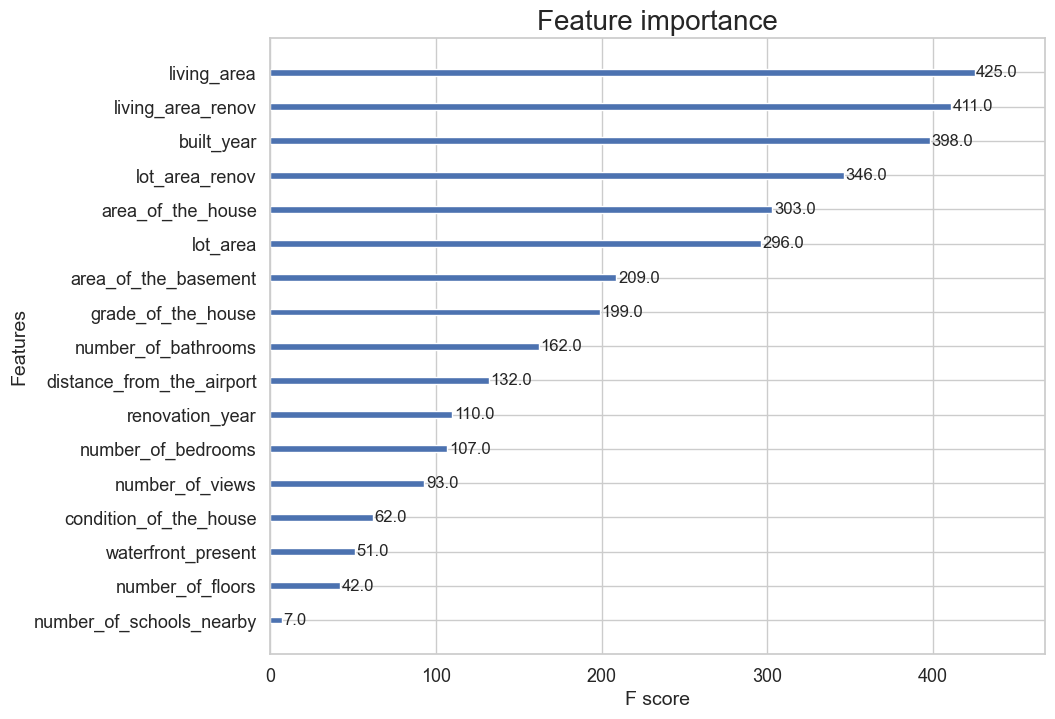

In [225]:
xgboost(df1, features, target)

Root Mean Squared Error: 192692.27928711477


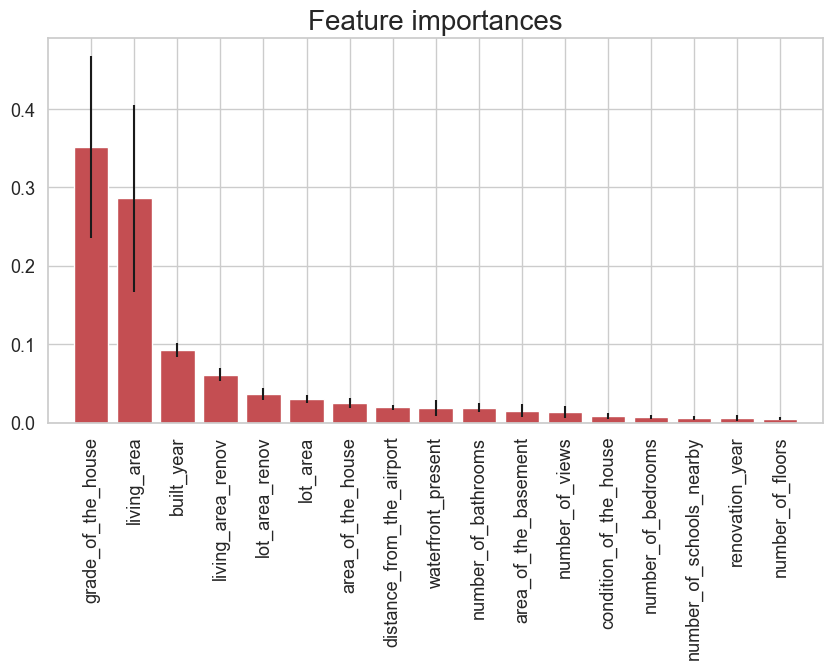

In [226]:
random_forest(df1, features, target)